# Exploratory Data Analysis on Retail Sales Data

## Objective
To explore retail sales data and identify sales trends, customer behaviour patterns, product performance, and actionable business insights.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [9]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
import os 
print(os.getcwd())

C:\Users\manas


In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 9)

Column Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [12]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [20]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numeric_columns].std())

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


### Observation

The monthly sales chart shows variations in sales over time. Some months have higher sales than others, indicating seasonal changes in customer purchasing behaviour.

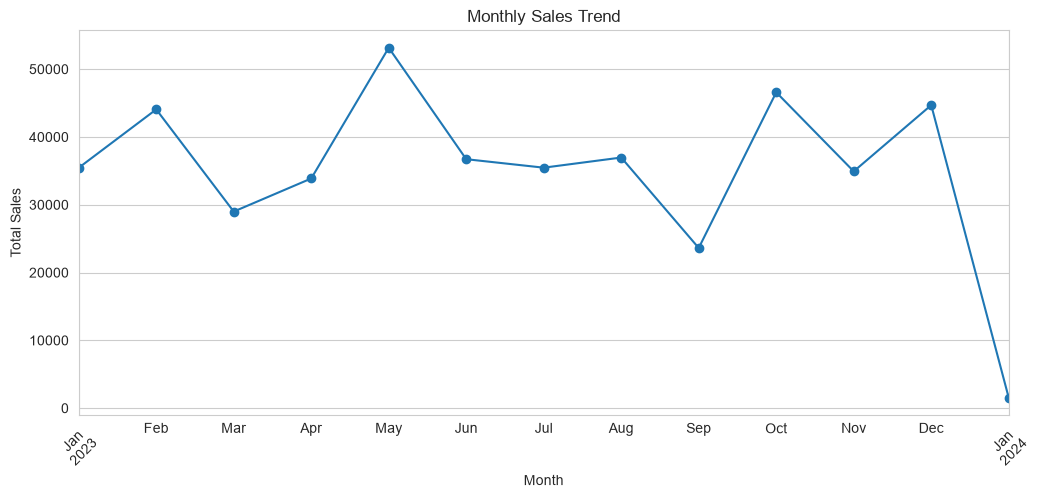

In [21]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot(kind='line', figsize=(12,5), marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

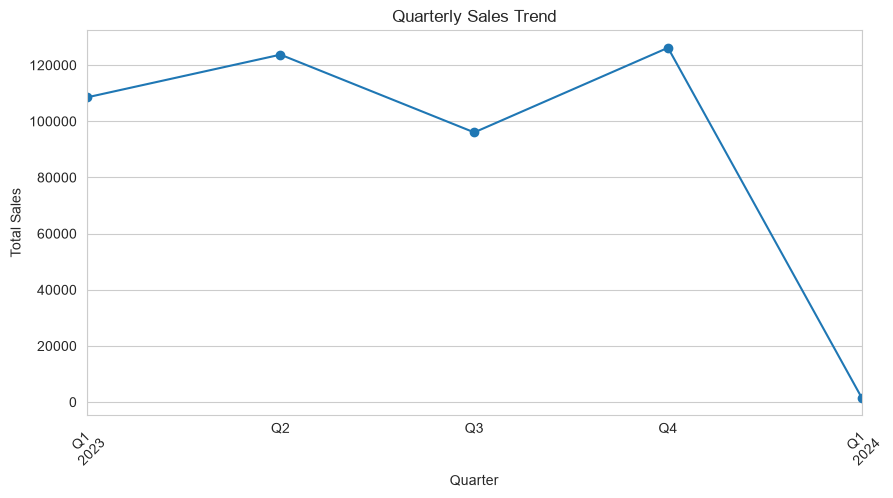

In [22]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales.plot(kind='line', figsize=(10,5), marker='o')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

### Observation

The age-group analysis shows which customer age group contributes the largest number of transactions. This can help the business understand its major customer segment.

In [25]:
bins = [0, 18, 25, 35, 45, 55, 100]

labels = [
    'Under 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

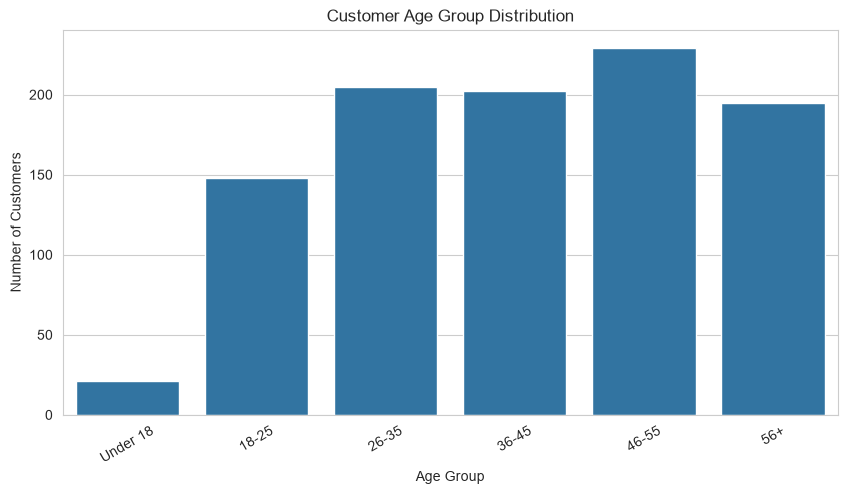

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Age Group'
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

### Observation

The gender distribution shows the proportion of customers across different genders and helps identify the dominant customer group.

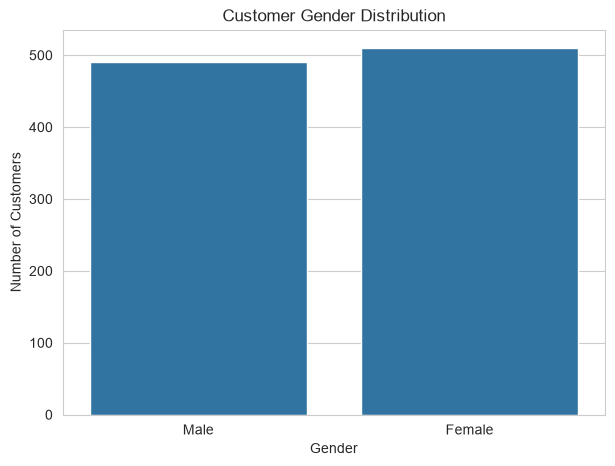

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The category revenue chart highlights the product categories generating the highest revenue. These categories may require more attention in inventory and marketing decisions.

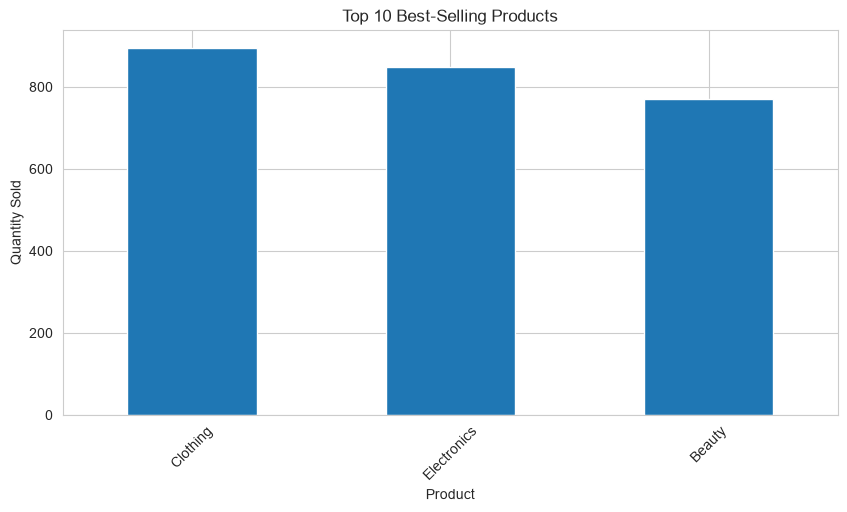

In [30]:
top_products = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables. Stronger correlations are represented by values closer to 1 or -1.

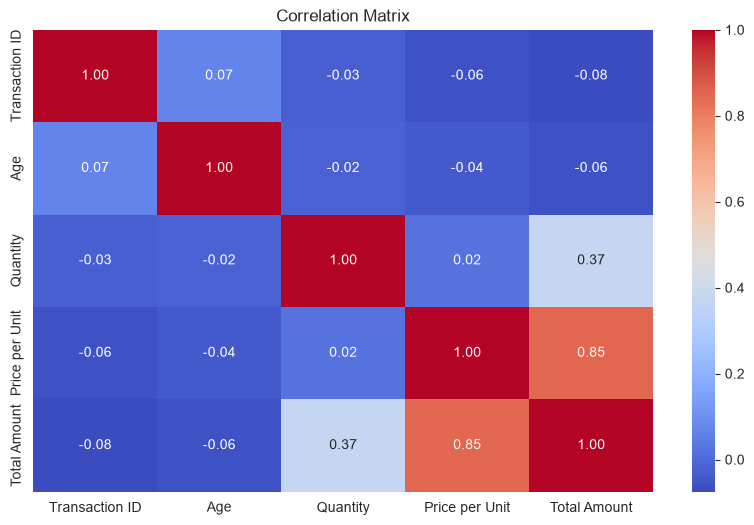

In [31]:
plt.figure(figsize=(10,6))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

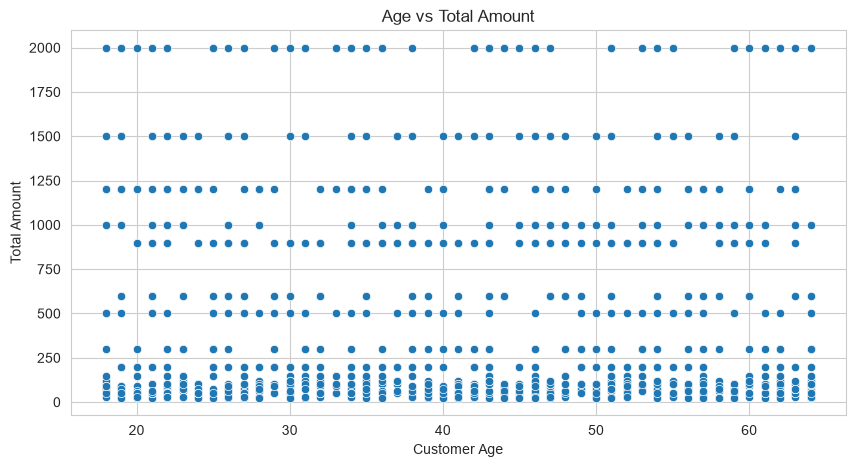

In [32]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Amount'
)

plt.title("Age vs Total Amount")
plt.xlabel("Customer Age")
plt.ylabel("Total Amount")

plt.show()

# Conclusion

The exploratory data analysis provided useful insights into retail sales performance, customer behaviour, and product trends.

## Key Findings

1. Monthly and quarterly sales trends show variations in sales performance over time.
2. Customer age-group analysis identifies the major customer segments.
3. Product category analysis highlights the categories contributing the most revenue.
4. Gender analysis provides an overview of the customer distribution.
5. Correlation analysis helps identify relationships between numerical variables.

## Business Recommendations

1. Focus marketing campaigns on the customer age groups contributing the highest number of transactions.
2. Maintain sufficient inventory for high-performing product categories to avoid stock shortages.
3. Use monthly sales trends to plan promotions and inventory before high-demand periods.
4. Monitor customer purchasing behaviour regularly to identify changes in demand.